# ML - Supervised Learning
## Logistic Regression
**Customer Purchase Prediction**   

In [2]:
# Create the DataFrame
import numpy as np
import pandas as pd

data = {
    "Age": [18, 20, 22, 25, 28, 30, 35, 40, 45, 50],
    "Purchased": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
print(df)

   Age  Purchased
0   18          0
1   20          0
2   22          0
3   25          0
4   28          1
5   30          1
6   35          1
7   40          1
8   45          1
9   50          1


In [3]:
# ============================================================
# TASKS 2–6: Weights, linear score, sigmoid, prediction
# ============================================================

# --- Task 2: Fixed parameters ------------------------------
w = 0.5
b = -13

# --- Task 3: Linear score  Z = wX + b ----------------------
df["Z"] = w * df["Age"] + b

# --- Task 4: Sigmoid probability  P = 1 / (1 + e^-Z) -------
df["Probability"] = 1 / (1 + np.exp(-df["Z"]))

# --- Task 5 & 6: Classification rule -----------------------
df["Prediction"] = np.where(
    df["Probability"] >= 0.5,
    1,
    0
)

# --- Task 7: Display the final DataFrame -------------------
print(df)

   Age  Purchased     Z  Probability  Prediction
0   18          0  -4.0     0.017986           0
1   20          0  -3.0     0.047426           0
2   22          0  -2.0     0.119203           0
3   25          0  -0.5     0.377541           0
4   28          1   1.0     0.731059           1
5   30          1   2.0     0.880797           1
6   35          1   4.5     0.989013           1
7   40          1   7.0     0.999089           1
8   45          1   9.5     0.999925           1
9   50          1  12.0     0.999994           1


In [7]:
# Test new customers

new_customers = pd.DataFrame({
    "Age": [21, 27, 32, 42]
})

# Calculate Z
new_customers["Z"] = w * new_customers["Age"] + b

# Calculate probability
new_customers["Probability"] = 1 / ( 1 + np.exp(-new_customers["Z"]))

# Make prediction
new_customers["Prediction"] = np.where(new_customers["Probability"] >= 0.5,
                                       "Purchased",
                                       "Not Purchased")

#print(new_customers)

print(new_customers[["Age", "Prediction"]])

   Age     Prediction
0   21  Not Purchased
1   27      Purchased
2   32      Purchased
3   42      Purchased


In [9]:
# Create 100 age values

curve = pd.DataFrame({
    "Age": np.linspace(18, 50, 100)
})

curve["Z"] = w * curve["Age"] + b

curve["Probability"] = 1 / (
    1 + np.exp(-curve["Z"])
)


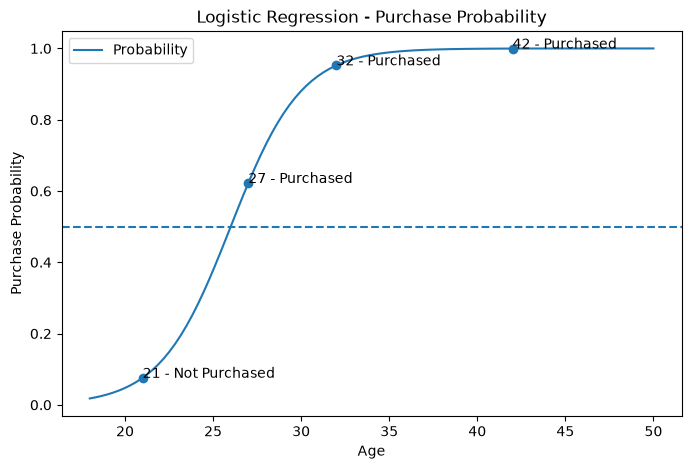

In [11]:
# Plot S-shaped curve

import matplotlib.pyplot as plt
ax = curve.plot(
    x="Age",
    y="Probability",
    kind="line",
    title="Logistic Regression - Purchase Probability",
    figsize=(8, 5)
)

# --------------------------------
# 9. Plot new customers
# --------------------------------

ax.scatter(
    new_customers["Age"],
    new_customers["Probability"]
)

# Add customer age labels
for i in range(len(new_customers)):
    ax.annotate(
        f"{new_customers.loc[i, 'Age']} - "
        f"{new_customers.loc[i, 'Prediction']}",
        (
            new_customers.loc[i, "Age"],
            new_customers.loc[i, "Probability"]
        )
    )

# Classification threshold
ax.axhline(
    y=0.5,
    linestyle="--"
)

ax.set_xlabel("Age")
ax.set_ylabel("Purchase Probability")

plt.show()